### 🫆 Column Transformer

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = r"columntransformer_toy_dataset.csv"

data

'columntransformer_toy_dataset.csv'

In [15]:
df = pd.read_csv(data)

df.head()



,Age,Salary,Education,City,Department,Gender,Experience
0,22.0,350000.0,Bachelor,Hyderabad,IT,Male,1.0
1,25.0,520000.0,Master,Bangalore,HR,Female,3.0
2,28.0,750000.0,Master,Chennai,IT,Male,5.0
3,31.0,1200000.0,PhD,Hyderabad,Finance,Female,8.0
4,35.0,1800000.0,PhD,Mumbai,IT,Male,11.0


In [89]:
X_train,X_test,y_train,y_test = train_test_split(df.drop("Salary",axis=1),df["Salary"],test_size=.3,random_state=42)

df.isnull().sum()

Age           1
Salary        5
Education     0
City          2
Department    1
Gender        2
Experience    1
dtype: int64

In [90]:
numerical_cols = ["Age","Experience"]

categorical_ordinal = ["Education"]

categorical_onehot = ["Department","City","Gender"]

categorical_cols = categorical_ordinal + categorical_onehot

numerical_cols,categorical_onehot,categorical_ordinal,categorical_cols

(['Age', 'Experience'],
 ['Department', 'City', 'Gender'],
 ['Education'],
 ['Education', 'Department', 'City', 'Gender'])


=================================================================================================================================

### Transformer Pipeline

```text
                    Dataset
                       │
          ┌────────────┴────────────┐
          │                         │
     Numerical                 Categorical
          │                         │
   ┌──────┴──────┐          ┌───────┴────────┐
   │             │          │                │
Imputer      StandardScaler  OrdinalEncoder  OneHotEncoder
   │             │          │                │
Age          Age/Salary    Education      City/Dept/Gender
Salary       Experience
Experience

```

=================================================================================================================================


In [22]:
df["Education"].value_counts()

Education
Bachelor    11
Master      10
PhD          9
Name: count, dtype: int64

In [91]:
transformer = ColumnTransformer(transformers=[
    
    ("numerical",SimpleImputer(strategy="median"),numerical_cols),
    ("categorical",SimpleImputer(strategy="most_frequent"),categorical_cols),
    ("standardizer",StandardScaler(),numerical_cols),
    ("ordinal",OrdinalEncoder(categories=[["Bachelor","Master","PhD"]]),categorical_ordinal),
    ("onehot",OneHotEncoder(handle_unknown="ignore",sparse_output=False),categorical_onehot)
    
    ],remainder="passthrough")

In [92]:
X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

X_train_transformed.shape,X_test_transformed.shape

((21, 23), (9, 23))

In [93]:
X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns=transformer.get_feature_names_out(),
    index=X_train.index
)

X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=transformer.get_feature_names_out(),
    index=X_test.index
)

In [94]:
print(X_train_transformed_df.columns)

Index(['numerical__Age', 'numerical__Experience', 'categorical__Education',
       'categorical__Department', 'categorical__City', 'categorical__Gender',
       'standardizer__Age', 'standardizer__Experience', 'ordinal__Education',
       'onehot__Department_Finance', 'onehot__Department_HR',
       'onehot__Department_IT', 'onehot__Department_Marketing',
       'onehot__Department_nan', 'onehot__City_Bangalore',
       'onehot__City_Chennai', 'onehot__City_Delhi', 'onehot__City_Hyderabad',
       'onehot__City_Mumbai', 'onehot__City_Pune', 'onehot__City_nan',
       'onehot__Gender_Female', 'onehot__Gender_Male'],
      dtype='object')


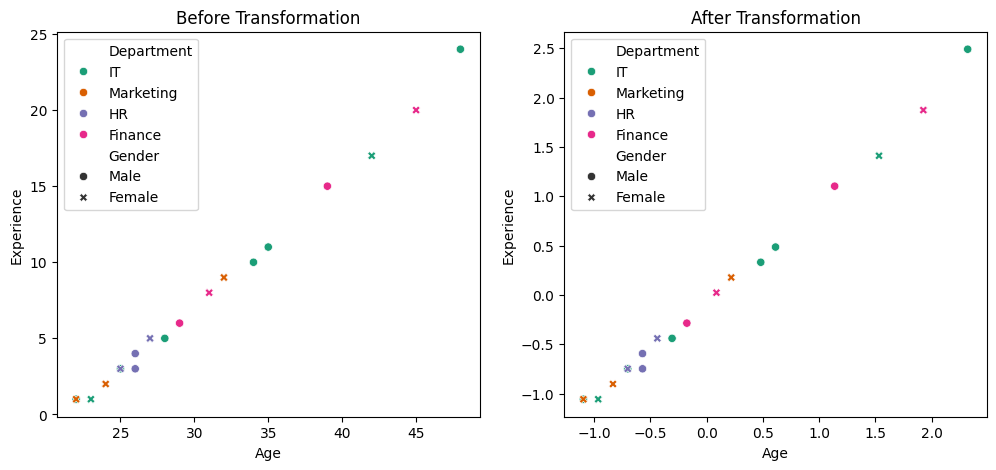

In [95]:
# "After" frame: transformed numeric columns + original labels for hue/style
after = pd.DataFrame({
    "Age": X_train_transformed_df["standardizer__Age"],
    "Experience": X_train_transformed_df["standardizer__Experience"],
    "Department": X_train["Department"],
    "Gender": X_train["Gender"],
})

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Transformation")
sns.scatterplot(
    data=X_train, x="Age", y="Experience",
    hue="Department", style="Gender", ax=ax1,palette="Dark2"
)

ax2.set_title("After Transformation")
sns.scatterplot(
    data=after, x="Age", y="Experience",
    hue="Department", style="Gender", ax=ax2,palette="Dark2"
)

plt.show()

In [ ]:
y_pred = model.predict(X_test_transformed)

print("R²  :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

results = pd.DataFrame({"Actual": y_test, "Predicted": y_pred.round(0)})
print(results)

# ---------- 6. Coefficients ----------
coefs = pd.Series(model.coef_, index=X_train_transformed.columns)
print(coefs.sort_values(ascending=False))

# ---------- 7. Predict for a new person ----------
new_person = pd.DataFrame([{
    "Age": 30,
    "Education": "Master",
    "City": "Bangalore",
    "Department": "IT",
    "Gender": "Female",
    "Experience": 6,
}])

new_transformed = transformer.transform(impute(new_person))
print("Predicted salary:", model.predict(new_transformed)[0])